In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv('data/final_data.csv')
df.head()

,Sample_ID,Label,Value_R,Value_C,Magnitude_0,Magnitude_1,Magnitude_2,Magnitude_3,Magnitude_4,Magnitude_5,...,Phase_5,Phase_6,Phase_7,Phase_8,Phase_9,Phase_10,Phase_11,Phase_12,Phase_13,Phase_14
0,1,nothing,0.0,0.0,139435.593,170791.421,176258.484,135388.687,215221.218,196589.843,...,175.297,-163.614,-171.446,-163.435,-158.626,-168.840,-157.760,-161.634,-160.782,-152.673
1,2,nothing,0.0,0.0,1171894.875,163993.812,1542996.750,441958.310,333872.593,700793.187,...,-26.154,18.430,78.518,51.747,9.166,43.648,39.437,20.472,19.448,24.981
2,3,nothing,0.0,0.0,360081.312,183087.625,680353.562,378817.000,374421.812,535006.375,...,-26.310,-110.969,93.626,70.853,-12.300,81.700,14.597,9.510,16.307,-18.706
3,4,nothing,0.0,0.0,331647.343,191307.578,834786.500,354133.187,404361.750,487509.406,...,-23.742,-101.964,79.179,78.230,-16.494,87.193,23.300,4.200,-3.430,-15.823
4,5,nothing,0.0,0.0,207994.593,159652.218,1089567.250,305106.218,486771.343,875787.562,...,-16.320,138.530,-8.710,37.952,175.100,-29.863,-40.171,-44.318,-37.201,78.420


C:\Users\Admin\AppData\Local\Temp\ipykernel_3016\828660606.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


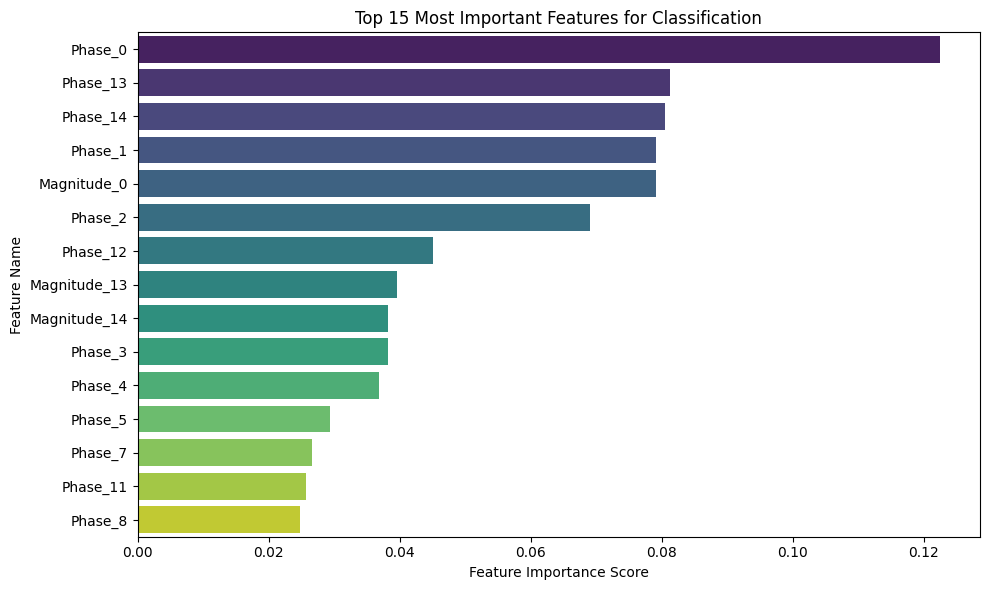

In [4]:
df = pd.read_csv('data/final_data.csv')

X = df.drop(columns=['Sample_ID', 'Label', 'Value_R', 'Value_C'])
y = df['Label']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

feature_scores = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = feature_scores.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Most Important Features for Classification')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_3016\545278322.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=index_scores.values, y=index_scores.index, palette='viridis')


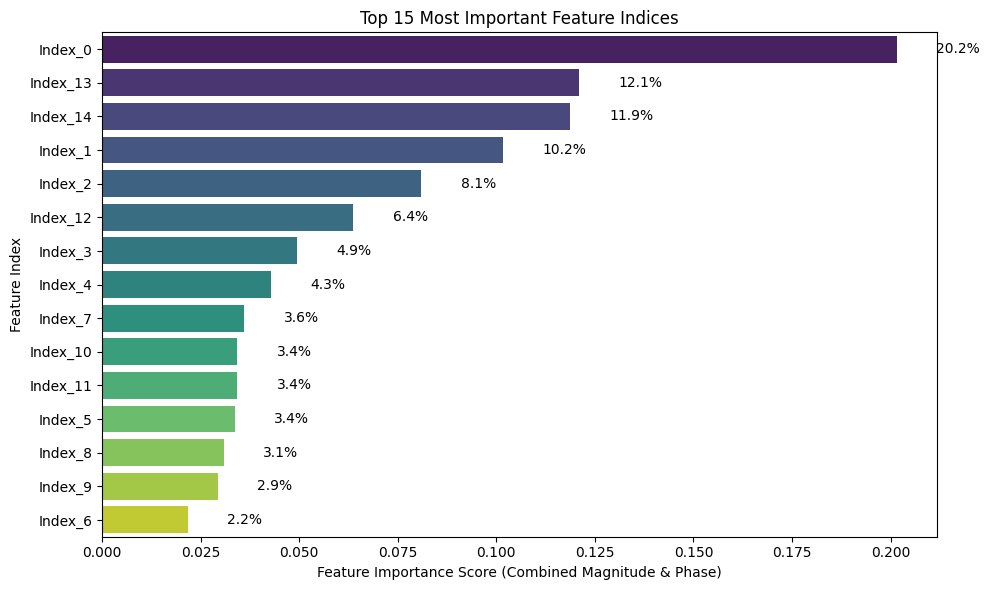

In [5]:
feature_scores = pd.Series(rf_model.feature_importances_, index=X.columns)
index_importance = {}

for i in range(15):
    mag_col = f'Magnitude_{i}'
    phase_col = f'Phase_{i}'
    
    sum_score = 0
    if mag_col in feature_scores:
        sum_score += feature_scores[mag_col]
    if phase_col in feature_scores:
        sum_score += feature_scores[phase_col]
        
    index_importance[f'Index_{i}'] = sum_score

index_scores = pd.Series(index_importance).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=index_scores.values, y=index_scores.index, palette='viridis')
plt.title('Top 15 Most Important Feature Indices')
plt.xlabel('Feature Importance Score (Combined Magnitude & Phase)')
plt.ylabel('Feature Index')

for i, v in enumerate(index_scores.values):
    plt.text(v + 0.01, i, f"{v*100:.1f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()


In [6]:
# Load data
df = pd.read_csv('data/final_data.csv')

X = df[[col for col in df.columns if 'Magnitude' in col or 'Phase' in col]]
y = df['Label']

# Train Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

#feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importance)

Phase_0         0.122492
Phase_13        0.081328
Phase_14        0.080470
Phase_1         0.079177
Magnitude_0     0.079103
Phase_2         0.069071
Phase_12        0.045116
Magnitude_13    0.039628
Magnitude_14    0.038285
Phase_3         0.038254
Phase_4         0.036806
Phase_5         0.029400
Phase_7         0.026661
Phase_11        0.025638
Phase_8         0.024819
Magnitude_1     0.022585
Phase_10        0.021135
Magnitude_12    0.018585
Phase_6         0.018078
Magnitude_9     0.014746
Phase_9         0.014659
Magnitude_10    0.013104
Magnitude_2     0.011842
Magnitude_3     0.011132
Magnitude_7     0.009419
Magnitude_11    0.008581
Magnitude_8     0.006076
Magnitude_4     0.006001
Magnitude_5     0.004206
Magnitude_6     0.003605
dtype: float64


In [7]:
from sklearn.svm import LinearSVC
import numpy as np

#Using L1 regularization to get feature importance
l1_svm = LinearSVC(penalty='l1', dual=False, C=0.1, random_state=42)
l1_svm.fit(X, y)

# Weights of features
weights = np.abs(l1_svm.coef_[0])
feature_weights = pd.Series(weights, index=X.columns).sort_values(ascending=False)

print(feature_weights)

Phase_0         0.051625
Phase_5         0.019210
Phase_14        0.014510
Phase_13        0.012036
Phase_2         0.011284
Phase_6         0.010947
Phase_9         0.010300
Phase_4         0.009616
Phase_8         0.006528
Magnitude_14    0.005960
Phase_7         0.004408
Phase_12        0.003989
Magnitude_13    0.003119
Magnitude_12    0.002342
Phase_3         0.002274
Phase_11        0.001864
Phase_1         0.001257
Magnitude_10    0.001236
Magnitude_11    0.001012
Magnitude_9     0.000941
Magnitude_3     0.000860
Magnitude_8     0.000437
Magnitude_1     0.000401
Magnitude_4     0.000395
Magnitude_6     0.000365
Magnitude_5     0.000286
Magnitude_0     0.000272
Magnitude_2     0.000246
Magnitude_7     0.000171
Phase_10        0.000048
dtype: float64


c:\TUC\Mini-Belt Characterization System\mini-belt-characterization\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C:\Users\Admin\AppData\Local\Temp\ipykernel_3016\3599921665.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=svm_index_scores.values, y=svm_index_scores.index, palette='rocket')


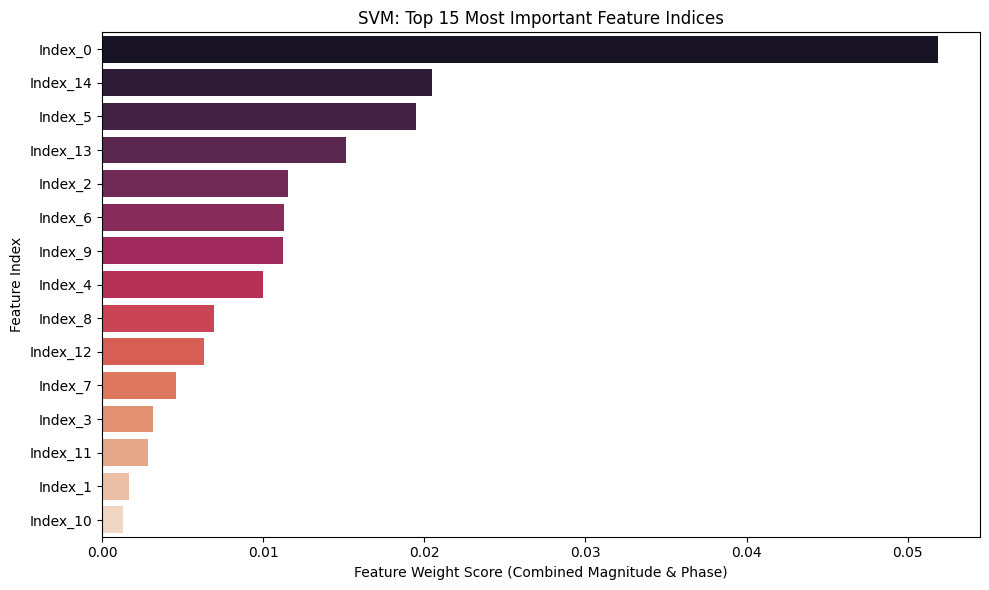


=== SVM Feature Ranking by Frequency ===
Index_0     0.051897
Index_14    0.020470
Index_5     0.019496
Index_13    0.015156
Index_2     0.011530
Index_6     0.011312
Index_9     0.011241
Index_4     0.010011
Index_8     0.006965
Index_12    0.006331
Index_7     0.004579
Index_3     0.003134
Index_11    0.002876
Index_1     0.001659
Index_10    0.001284
dtype: float64


In [8]:
# SVM Feature Ranking by Frequency Index (similar to Random Forest)

svm_index_importance = {}

for i in range(15):
    mag_col = f'Magnitude_{i}'
    phase_col = f'Phase_{i}'
    
    sum_weight = 0
    if mag_col in feature_weights.index:
        sum_weight += feature_weights[mag_col]
    if phase_col in feature_weights.index:
        sum_weight += feature_weights[phase_col]
        
    svm_index_importance[f'Index_{i}'] = sum_weight

svm_index_scores = pd.Series(svm_index_importance).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=svm_index_scores.values, y=svm_index_scores.index, palette='rocket')
plt.title('SVM: Top 15 Most Important Feature Indices')
plt.xlabel('Feature Weight Score (Combined Magnitude & Phase)')
plt.ylabel('Feature Index')

# for i, v in enumerate(svm_index_scores.values):
#     plt.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== SVM Feature Ranking by Frequency ===")
print(svm_index_scores)


=== Comparison: Random Forest vs SVM ===
          Random Forest    SVM L1
Index_0        0.201596  0.051897
Index_1        0.101761  0.001659
Index_10       0.034239  0.001284
Index_11       0.034219  0.002876
Index_12       0.063700  0.006331
Index_13       0.120956  0.015156
Index_14       0.118755  0.020470
Index_2        0.080913  0.011530
Index_3        0.049386  0.003134
Index_4        0.042806  0.010011
Index_5        0.033606  0.019496
Index_6        0.021683  0.011312
Index_7        0.036080  0.004579
Index_8        0.030895  0.006965
Index_9        0.029405  0.011241


C:\Users\Admin\AppData\Local\Temp\ipykernel_3016\3858521810.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=None, y=index_scores.head(ranking_num).index, x=index_scores.head(ranking_num).values, ax=axes[0], palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_3016\3858521810.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=None, y=svm_index_scores.head(ranking_num).index, x=svm_index_scores.head(ranking_num).values, ax=axes[1], palette='rocket')


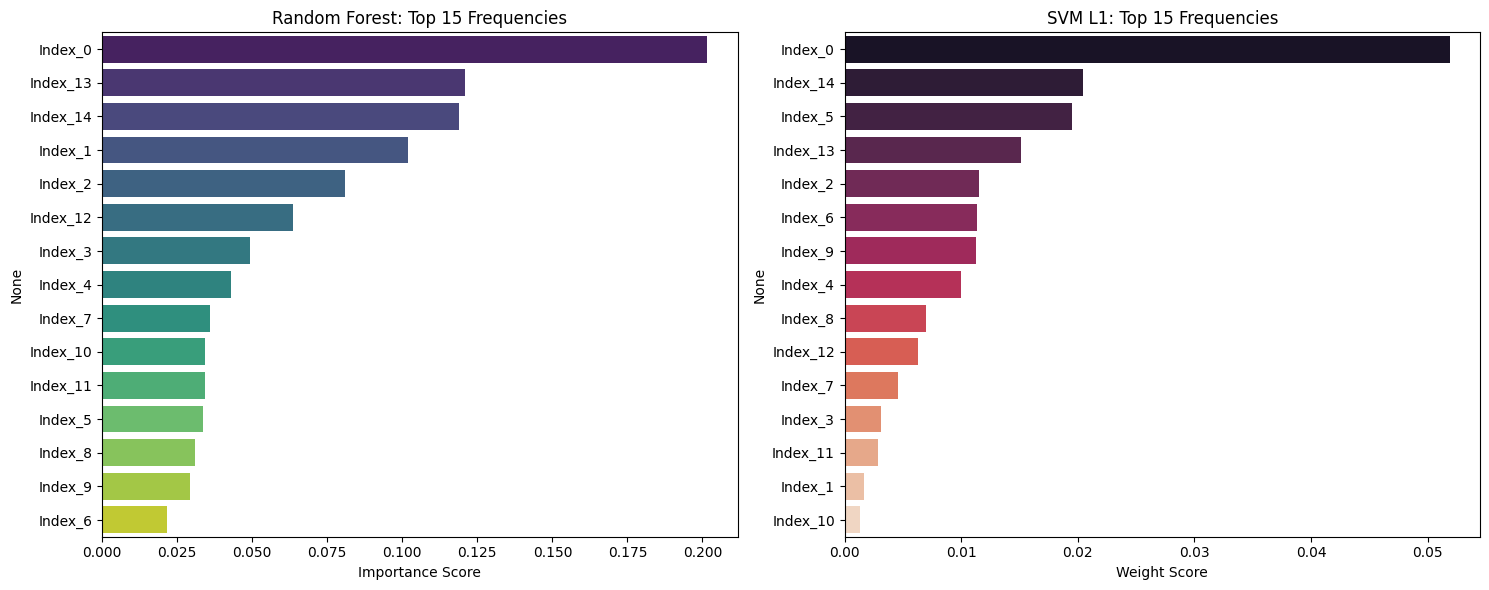

: 

In [ ]:
comparison_df = pd.DataFrame({
    'Random Forest': index_scores.head(15),
    'SVM L1': svm_index_scores.head(15)
})

print("\n=== Comparison: Random Forest vs SVM ===")
print(comparison_df)
ranking_num = 15

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest
sns.barplot(data=None, y=index_scores.head(ranking_num).index, x=index_scores.head(ranking_num).values, ax=axes[0], palette='viridis')
axes[0].set_title(f'Random Forest: Top {ranking_num} Frequencies')
axes[0].set_xlabel('Importance Score')

# SVM
sns.barplot(data=None, y=svm_index_scores.head(ranking_num).index, x=svm_index_scores.head(ranking_num).values, ax=axes[1], palette='rocket')
axes[1].set_title(f'SVM L1: Top {ranking_num} Frequencies')
axes[1].set_xlabel('Weight Score')

plt.tight_layout()
plt.show()